# 5.1 导读与数学基础：向量、多兴趣与序列召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入 DSSM、MIND 与 SASRec 前，理解向量空间、对比学习、ANN、多兴趣、位置编码、因果注意力和 Top-K 指标。

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews 2023 Video Games 5-core：召回章节导读与汇总**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/) · [MIND](https://arxiv.org/abs/1904.08030) · [SASRec](https://arxiv.org/abs/1808.09781) · [BERT4Rec](https://arxiv.org/abs/1904.06690) · [HSTU](https://arxiv.org/abs/2402.17152) · [YouTube DNN](https://research.google/pubs/deep-neural-networks-for-youtube-recommendations/)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "amazon-2023"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'amazon-2023', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 用户表示 | 检索次数 | 优势 | 主要代价 |
|---|---:|---:|---|---|
| 5.2 DSSM | 1 个向量 | 1 | 简单、低延迟、ANN 友好 | 多兴趣被平均 |
| 5.3 MIND | K 个兴趣向量 | K | 覆盖多意图与长尾 | 路由、合并、去重成本 |
| 5.4 SASRec | 1 个时序向量 | 1 | 捕捉近期转移与顺序依赖 | Attention 成本与序列延迟 |
| 5.5 总结 | 读取三个实验结果 | — | 同口径看 Recall 与成本 | smoke 不是 benchmark |

DSSM 适合通用亿级目录；MIND 适合同时存在多个意图；SASRec 适合下一行为受先后顺序和近期行为影响明显的场景。三者最终都能产生可用于全库检索的用户表示。

## 来源论文解读

- **Huang et al. (2013)** 用搜索点击数据让 query/document 表示进入同一语义空间，并以 NDCG 验证。原文没有评测推荐或 ANN；后来推荐系统才把这一结构迁移为 user/item 双塔。
- **YouTube DNN (2016)** 明确区分 candidate generation 与 ranking，并讨论 sampled softmax 和训练/服务分布。
- **MIND (2019)** 用动态路由抽取多个兴趣胶囊，训练时根据目标选择相关兴趣。
- **SASRec (2018)** 用因果自注意力在每个位置预测下一物品。服务时取最后有效位置的表示，与全库 item embedding 点积，因此主要落在序列召回，也可把序列表征提供给排序。
- **BERT4Rec (2019)** 改用双向上下文与 masked-item 训练，更适合离线表征和补全式预训练，但与在线 next-item 的信息边界不同。
- **HSTU (2024)** 面向高基数、非平稳、超长行为流重新设计注意力和系统实现；它在 4.3 继续展开，不与 SASRec 的轻量实验混为同一规模结论。

论文中的离线提升不等于任意目录上的线上增益；负采样、索引新鲜度和候选合并常比换一层 MLP 更重要。

## 共同数学：先修清单

| 知识点 | 最低需要会什么 | 本章在哪里使用 |
|---|---|---|
| 向量与长度 | 会算 $\sqrt{x_1^2+\cdots+x_d^2}$ | 归一化、余弦、squash |
| 点积与矩阵乘法 | 点积是对应坐标相乘再相加；矩阵乘法是批量点积 | 双塔全库分数、QKᵀ |
| 指数、对数 | 指数放大差异；对数把连乘变连加 | Softmax、负对数损失 |
| 条件概率 | “已知用户后，目标物品出现的概率” | DSSM/MIND sampled softmax |
| 加权和 | 权重越大，该向量对结果贡献越大 | MIND 路由、SASRec attention |
| 序列下标 | 第 t 个位置只能用 1…t | SASRec 因果 mask |
| Top-K 指标 | 区分“是否找回”和“排得多靠前” | Recall/HitRate/NDCG |

不需要先修完整微积分课程。阅读顺序固定为：先看输入形状，再算分数，再把分数变成概率/权重，最后理解损失为什么会推动正确答案上升。

### 1. 点积、余弦与批量计算

点积 $u^\top v=\sum_ru_rv_r$ 是“对应坐标相乘再相加”。归一化向量的内积等于余弦相似度：

$$\cos(u,v)=\frac{u^\top v}{\|u\|_2\|v\|_2}.$$

若一批用户是 $U\in\mathbb R^{B\times d}$，物品库是 $V\in\mathbb R^{N\times d}$，那么 $UV^\top\in\mathbb R^{B\times N}$ 的每个格子就是一对 user-item 分数。

### 2. 从分数到概率：Softmax、温度与负对数

对一个正物品和若干负物品，可用

$$P(i^+|u)=\frac{\exp(s(u,i^+)/\tau)}{\sum_j\exp(s(u,i_j)/\tau)}$$

训练，其中温度 $\tau$ 控制分布尖锐程度。$\tau$ 小会放大分数差，$\tau$ 大会让概率更平均。损失 $-\log P(i^+|u)$ 会重罚“正确物品概率很低”的情况。in-batch negative 把同一批次其他正物品当负样本，效率高，但其中可能有用户其实喜欢的假负样本。

### 3. 多兴趣：软分组与最大匹配

召回阶段常看 $\mathrm{Recall@K}=|TopK\cap Relevant|/|Relevant|$。DSSM 只有一个 $u$；MIND 使用 $K$ 个 $u_k$，候选分数为 $\max_k u_k^\top v_i$。

MIND 的路由权重对每条行为经 softmax 后和为 1，所以它是“可以同时属于多组、但总票数固定”的软分组。squash 函数保留兴趣方向并把长度压到 0～1。

### 4. 自注意力：问题、标签、内容与时间边界

SASRec 先令 $x_t=e(i_t)+p_t$，再计算

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V.$$

Q、K、V 可读作“问题、标签、内容”。$QK^\top$ 先得到每个位置对每段历史的相关分；除以 $\sqrt{d_k}$ 防止维度增大后分数过大；softmax 再把一行变成和为 1 的阅读权重。因果遮罩在未来位置填入 $-\infty$，使预测位置只能读取过去。最后有效位置向量就是随顺序变化的用户召回向量。

### 5. 指标边界

单真值时 HitRate@K 与 Recall@K 数值相同；NDCG@K 还会奖励更靠前的位置。论文若使用不同数据切分、候选集或负样本，即使指标名称相同也不能直接排名。

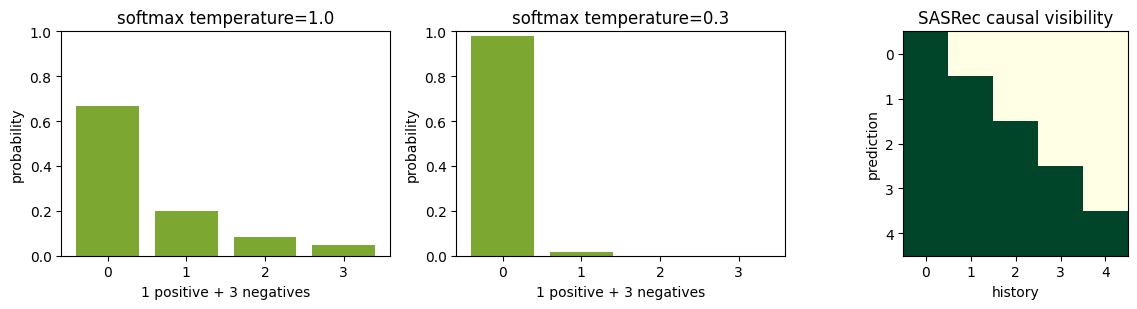

{'single_scores': [0.5, 0.5, -0.5], 'multi_interest_scores': [1.0, 1.0, 0.0]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
scores=np.array([2.4,1.2,.3,-.2]); temperatures=[1.0,.3]
fig,axes=plt.subplots(1,3,figsize=(12,3.2))
for ax,tau in zip(axes,temperatures):
    probability=np.exp(scores/tau); probability/=probability.sum()
    ax.bar(range(len(scores)),probability,color='#7ca832'); ax.set(title=f'softmax temperature={tau}',xlabel='1 positive + 3 negatives',ylabel='probability',ylim=(0,1))
causal=np.tril(np.ones((5,5))); axes[2].imshow(causal,cmap='YlGn'); axes[2].set(title='SASRec causal visibility',xlabel='history',ylabel='prediction')
plt.tight_layout(); plt.show()
single=np.array([.5,.5]); interests=np.array([[1.,0.],[0.,1.]]); candidates=np.array([[1.,0.],[0.,1.],[-1.,0.]])
print({'single_scores':(candidates@single).tolist(),'multi_interest_scores':(interests@candidates.T).max(0).tolist()})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
def recall_at_k(ranked,relevant,k):
    return len(set(ranked[:k])&set(relevant))/len(relevant)
assert recall_at_k([2,5,1,7],[1,2,8],3)==2/3
print('PASS：Softmax 概率、单/多兴趣分数与 Recall 示例正确。')

PASS：Softmax 概率、单/多兴趣分数与 Recall 示例正确。


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。